# fMRI Connectomics & Machine Learning Pipeline

Today, you will build a complete functional Magnetic Resonance Imaging (fMRI) pipeline: from raw-ish BOLD signals to brain connectivity graphs, and finally to a machine learning classifier.

For this exercise you only need a normal Python runtime type, as we won't need GPUs.

Let's start by installing and importing the right packages

In [1]:
# Installing nilearn package
!pip install nilearn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from networkx.algorithms import community

from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

## Exercise 1: Loading & Visualising Brain Data

We will use the **Schaefer 2018 atlas** (100 regions) to parcellate the brain. The Schaefer atlas is available in multiple "resolutions". You can ask for 100, 200, 400, or up to 1000 ROIs. You can also ask for them to be mapped to either 7 or 17 networks. For the pipeline that you will develop, the ML model will use the connections between the 100 regions. But later, when you visualise the most important edges, knowing the rough 7 networks can be helpful for interpretation. You can ignore this detail for the rest of the exercise, and use this information to just know how to call the right functions.

Then, we will load 50 subjects from the **Development fMRI dataset** (predicting Child vs. Adult). This dataset has 155 subjects available, but given the time it takes, we will start with only 50 - you'll see that despite this small number, Colab still takes quite a while in some steps, showing once again the challenges of typical biomedical data.


**Pointers:**
1. Fetch the Schaefer 2018 atlas with 100 ROIs and 7 networks.
2. Plot the atlas over a standard MRI template.
3. Fetch the Development dataset (`n_subjects=50`).
4. Extract the target labels (1 for Child, 0 for Adult).

In [ ]:
# atlas = datasets.fetch_...
# plotting.plot_roi(...)
# dev_data = datasets.fetch_development_fmri(...)

Fetching Schaefer Atlas...


[fetch_atlas_schaefer_2018] Dataset found in /root/nilearn_data/schaefer_2018

Plotting Atlas...


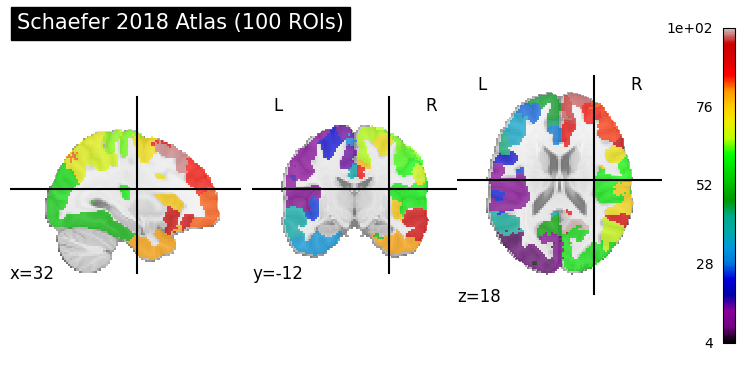

Fetching Development dataset (50 subjects)...


[fetch_development_fmri] Dataset found in /root/nilearn_data/development_fmri

[fetch_development_fmri] Dataset found in /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Dataset found in /root/nilearn_data/development_fmri/development_fmri

Loaded 50 subjects. Classes: [11 39] (0=Adult, 1=Child)


In [10]:
# SOLUTION
print("Fetching Schaefer Atlas...")
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7, resolution_mm=2)

print("Plotting Atlas...")
plotting.plot_roi(atlas.maps, title="Schaefer 2018 Atlas (100 ROIs)", cmap='nipy_spectral')
plt.show()

print("Fetching Development dataset (50 subjects)...")
dev_data = datasets.fetch_development_fmri(n_subjects=50)
fmri_filenames = dev_data.func
confounds = dev_data.confounds

# Extract labels: The phenotypic data contains byte strings, so we decode them
phenotypic = dev_data.phenotypic
labels = np.array([1 if x == 'child' else 0 for x in phenotypic['Child_Adult']])

print(f"Loaded {len(fmri_filenames)} subjects. Classes: {np.bincount(labels)} (0=Adult, 1=Child)")

# Exercise 2: Extract Time-Series

Using Nilearn's `NiftiLabelsMasker`, extract the mean time-series for each of the 100 regions for all subjects. To be clear and to avoid potential data leakage, you need to calculate the mean for each patient independently.

*(This might take a few minutes on Colab)*

**Pointers:**
- Remember to pass the `confounds` to clean the signal of noise!
- Ensure the extracted signals are standardised(z-scored) per sample. This ensures the time-series are on a comparable scale across different subjects. Explore the parameters of `NiftiLabelsMasker` to find how to apply this scaling.

In [ ]:
# masker = NiftiLabelsMasker(...)
# time_series_all = []
# for img, conf in zip(fmri_filenames, confounds):
#     time_series = masker.fit_transform(...)
#     time_series_all.append(time_series)

In [11]:
# Solution
masker = NiftiLabelsMasker(labels_img=atlas.maps, standardize='zscore_sample',
                           memory='nilearn_cache', verbose=0)

time_series_all = []
print("Extracting time-series. This will take a few minutes...")
for i, (func_img, confound_file) in enumerate(zip(fmri_filenames, confounds)):
    if (i+1) % 25 == 0:
        print(f"Processed {i+1}/{len(fmri_filenames)} subjects...")
    time_series = masker.fit_transform(func_img, confounds=confound_file)
    time_series_all.append(time_series)

print(f"Done! Shape of first subject's time-series: {time_series_all[0].shape} (Timepoints x ROIs)")

Extracting time-series. This will take a few minutes...


/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_img, confounds=confound_file)
/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_img, confounds=confound_file)
/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_img, confounds=confound_file)
/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_img, confounds=confound_file)
/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: F

Processed 25/50 subjects...


/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_img, confounds=confound_file)
/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_img, confounds=confound_file)
/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_img, confounds=confound_file)
/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_img, confounds=confound_file)
/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: F

Processed 50/50 subjects...
Done! Shape of first subject's time-series: (168, 100) (Timepoints x ROIs)


/tmp/ipykernel_11234/3803990691.py:10: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_img, confounds=confound_file)


# Exercise 3: Computing Functional Connectivity

Compute standard **correlation** and **partial correlation** matrices from the previous timeseries.

**Pointers:**
1. Use `ConnectivityMeasure` to fit and transform the time series.
2. Plot the correlation matrix of the first subject and compare it to the partial correlation one.
3. Apply a **proportional threshold** (e.g., top 5% edges) and visualize the brain connectome using `plotting.plot_connectome`.

In [ ]:
# conn_corr = ConnectivityMeasure(kind=...)
# matrices_corr = ...
# ...
# plotting.plot_matrix(...)
# plotting.plot_connectome(...)


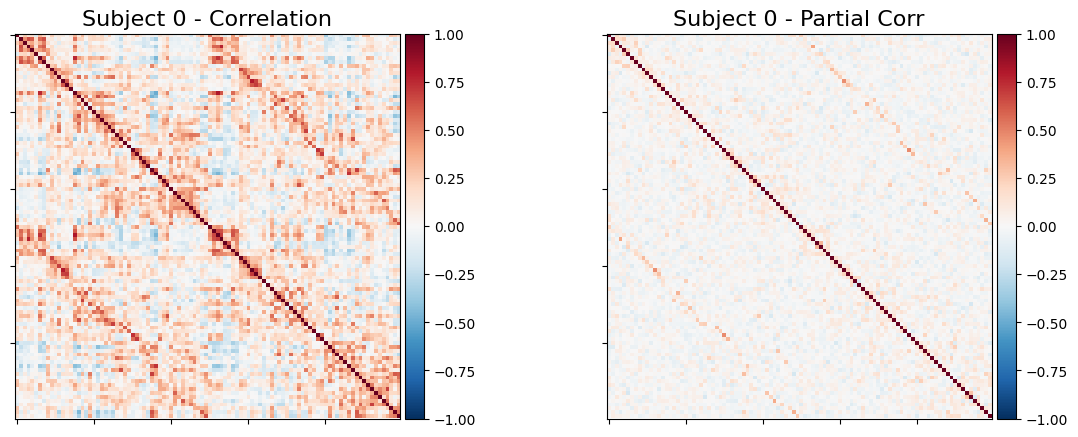

Connectome with 10% proportional threshold:


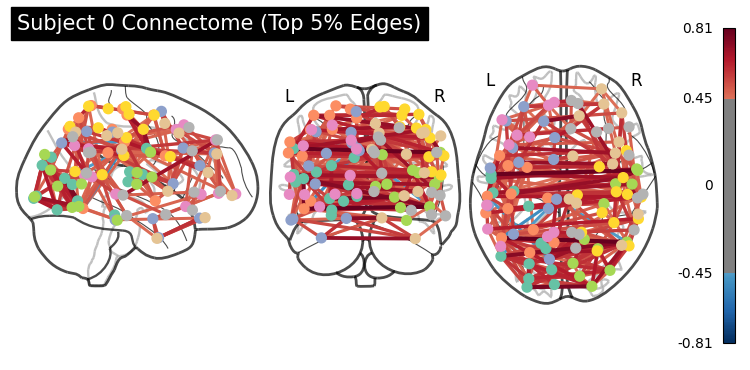

In [22]:
# SOLUTION
# Compute Correlation
conn_corr = ConnectivityMeasure(kind='correlation', standardize='zscore_sample')
matrices_corr = conn_corr.fit_transform(time_series_all)

# Compute Partial Correlation
conn_part = ConnectivityMeasure(kind='partial correlation')
matrices_part = conn_part.fit_transform(time_series_all)

# Extract node coordinates for plotting
coords = plotting.find_parcellation_cut_coords(labels_img=atlas.maps)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plotting.plot_matrix(matrices_corr[0], axes=axes[0], colorbar=True, vmax=1, vmin=-1, title="Subject 0 - Correlation")
plotting.plot_matrix(matrices_part[0], axes=axes[1], colorbar=True, vmax=1, vmin=-1, title="Subject 0 - Partial Corr")
plt.show()

print("Connectome with 10% proportional threshold:")
plotting.plot_connectome(matrices_corr[0], coords, edge_threshold="95%",
                         title="Subject 0 Connectome (Top 5% Edges)")
plotting.show()

## Exercise 4: Graph Analysis

Let's treat the brain as a graph $G = (V, E)$ to extract topological features.

**Pointers:**
1. Take the correlation matrix of the first subject.
2. Apply an **absolute threshold** (e.g., keep edges > 0.4) to create a binary adjacency matrix.
3. Convert this into a `NetworkX` graph.
4. Compute:
   - Average Clustering Coefficient
   - Top 3 nodes by Degree (hubs)
   - Top 3 nodes by Betweenness Centrality
   - Graph Modularity (using `nx.community.greedy_modularity_communities`)

In [ ]:
# ...
# adj_matrix = ... # Threshold the matrix
# ...
# G = nx.from_numpy_array(adj_matrix)
# ...
# clustering = nx.average_clustering(G)
# ...
# communities = community.greedy_modularity_communities(G)
# ...

Average Clustering Coefficient: 0.432
Top 3 Hubs by Degree (Node, Degree): [(15, 20), (6, 18), (52, 18)]
Top 3 Bottlenecks by Betweenness: [60, 74, 15]
Graph Modularity: 0.542 (Number of communities: 7)


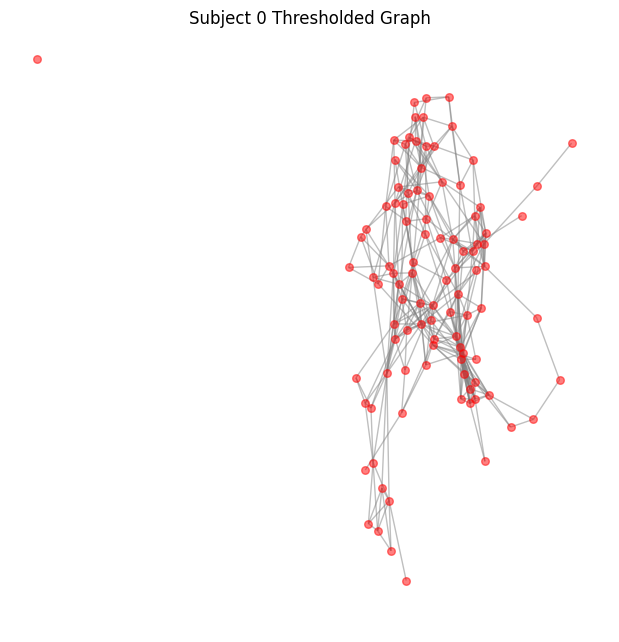

In [23]:
# 1 & 2: Absolute Thresholding
subj_0_corr = matrices_corr[0].copy()
np.fill_diagonal(subj_0_corr, 0) # Remove self-loops
adj_matrix = (np.abs(subj_0_corr) > 0.4).astype(int)

# 3: Convert to NetworkX
G = nx.from_numpy_array(adj_matrix)

# 4: Compute metrics
clustering = nx.average_clustering(G)

degrees = dict(G.degree())
top_degree = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:3]

betweenness = nx.betweenness_centrality(G)
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:3]

# Modularity
communities = community.greedy_modularity_communities(G)
modularity = community.modularity(G, communities)

print(f"Average Clustering Coefficient: {clustering:.3f}")
print(f"Top 3 Hubs by Degree (Node, Degree): {top_degree}")
print(f"Top 3 Bottlenecks by Betweenness: {[node for node, val in top_betweenness]}")
print(f"Graph Modularity: {modularity:.3f} (Number of communities: {len(communities)})")

# Quick Visualization
plt.figure(figsize=(6,6))
nx.draw_spring(G, node_size=30, node_color='red', edge_color='gray', alpha=0.5)
plt.title("Subject 0 Thresholded Graph")
plt.show()

# Exercise 5: Predicting Age Group (Child vs Adult) & Data Leakage

A common mistake in neuroimaging ML is **data leakage**.
Two common sources of leakage are:
1. **Feature Selection:** Selecting top features on the entire dataset before splitting into train/test folds.
2. **Tangent Embedding:** `ConnectivityMeasure(kind='tangent')` calculates a **group mean covariance matrix**. If you apply `.fit_transform()` on the entire dataset, information from the test subjects leaks into the spatial embedding of the training subjects!

In this exercise, compare two approaches using a Linear SVM and 5-fold Stratified cross-validation.
1. **The Leaky Way:** Apply `ConnectivityMeasure(kind='tangent', vectorize=True)` and `SelectKBest` on the *entire* list of time-series. Then run cross-validation.
2. **The Correct Pipeline Way:** Create an `sklearn.pipeline.Pipeline` containing the `ConnectivityMeasure`, `StandardScaler`, `SelectKBest`, and the `SVC`. This guarantees the Tangent mean and feature selection are **only** fit on the training data of each fold!

*Calculate AUROC and AUPRC for both to quantify performance*

In [ ]:
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# model = SVC(probability=True, kernel='linear')
# y = labels

# # 1. Leaky Way
# X_leaky_tangent = ConnectivityMeasure(...).fit_transform(time_series_all)
# X_leaky_selected = SelectKBest(...).fit_transform(X_leaky_tangent, y)
# ... cross_val_score ...

# # 2. Strict Pipeline
# strict_pipe = Pipeline([
#     ('conn', ConnectivityMeasure(...)),
#     ('scaler', StandardScaler()),
#     ('selector', SelectKBest(...)),
#     ('svm', model)
# ])
# ... cross_val_score ...

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = SVC(probability=True, kernel='linear', random_state=42)
y = labels

# ---------------------------------------------------------
# 1. THE LEAKY WAY (DO NOT DO THIS)
# ---------------------------------------------------------
# Leakage 1: Tangent group mean calculated on ALL data
conn_leaky = ConnectivityMeasure(kind='tangent', vectorize=True)
X_leaky = conn_leaky.fit_transform(time_series_all)

# Leakage 2: Feature selection looks at ALL labels
selector_leaky = SelectKBest(f_classif, k=100)
X_leaky_selected = selector_leaky.fit_transform(X_leaky, y)

# CV on leaked features
leaky_roc = cross_val_score(model, X_leaky_selected, y, cv=cv, scoring='roc_auc')
leaky_prc = cross_val_score(model, X_leaky_selected, y, cv=cv, scoring='average_precision')

# ---------------------------------------------------------
# 2. THE STRICT PIPELINE WAY (PROPER EVALUATION)
# ---------------------------------------------------------
# Everything goes inside the pipeline. The time_series_all (list of arrays)
# is passed directly into the CV loop!
strict_pipe = Pipeline([
    ('conn', ConnectivityMeasure(kind='tangent', vectorize=True)),
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif, k=100)),
    ('svm', model)
])

# We pass time_series_all directly to cross_val_score
strict_roc = cross_val_score(strict_pipe, time_series_all, y, cv=cv, scoring='roc_auc')
strict_prc = cross_val_score(strict_pipe, time_series_all, y, cv=cv, scoring='average_precision')

# Function to compute 95% CI
def calc_ci(scores):
    mean = np.mean(scores)
    ci = 1.96 * np.std(scores) / np.sqrt(len(scores))
    return mean, ci

roc_leaky_m, roc_leaky_ci = calc_ci(leaky_roc)
roc_strict_m, roc_strict_ci = calc_ci(strict_roc)
prc_leaky_m, prc_leaky_ci = calc_ci(leaky_prc)
prc_strict_m, prc_strict_ci = calc_ci(strict_prc)

print(f"--- AUROC (Mean ± 95% CI) ---")
print(f"Leaky Pipeline:  {roc_leaky_m:.3f} ± {roc_leaky_ci:.3f} (Artificially Inflated!)")
print(f"Strict Pipeline: {roc_strict_m:.3f} ± {roc_strict_ci:.3f} (Realistic Performance)")

print(f"\n--- AUPRC (Mean ± 95% CI) ---")
print(f"Leaky Pipeline:  {prc_leaky_m:.3f} ± {prc_leaky_ci:.3f}")
print(f"Strict Pipeline: {prc_strict_m:.3f} ± {prc_strict_ci:.3f}")

--- AUROC (Mean ± 95% CI) ---
Leaky Pipeline:  0.988 ± 0.022 (Artificially Inflated!)
Strict Pipeline: 0.900 ± 0.175 (Realistic Performance)

--- AUPRC (Mean ± 95% CI) ---
Leaky Pipeline:  0.997 ± 0.005
Strict Pipeline: 0.954 ± 0.080


# Exercise 6: Visualising the Model's Brain
Machine Learning in neuroscience is mostly about interpretation. Let's find out *which* brain connections distinguish children from adults.

**Pointers:**
1. Fit your **strict pipeline** on the *entire* dataset (this is fine now, because we are no longer evaluating, just inspecting the final model for deployment).
2. Extract the weights (coefficients) from the linear SVM.
3. Because we used `SelectKBest`, map these weights back to the full feature space.
4. Use `conn.inverse_transform()` to turn the 1D feature vector back into a 100x100 symmetric matrix.
5. Plot the top 1% of discriminative edges.

In [ ]:
# strict_pipe.fit(time_series_all, y)
# svm_weights = strict_pipe.named_steps['svm'].coef_[0]
# ... map weights back ...
# plotting.plot_connectome(...)

Visualising the most discriminative edges (Child vs Adult):


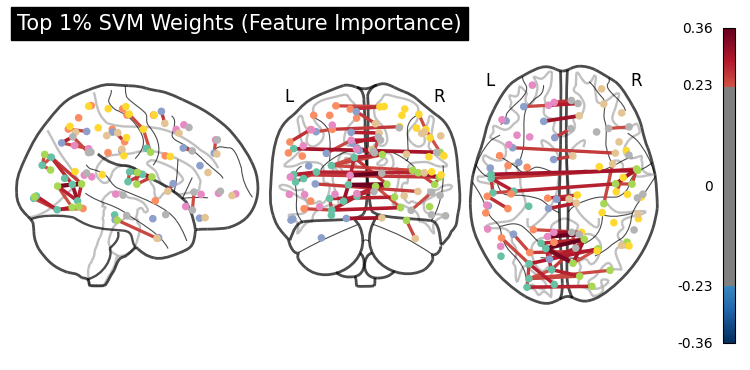

In [30]:
# SOLUTION
# Fit full pipeline to inspect weights
strict_pipe.fit(time_series_all, y)

# Get the components from the fitted pipeline
conn_step = strict_pipe.named_steps['conn']
selector_step = strict_pipe.named_steps['selector']
svm_step = strict_pipe.named_steps['svm']

svm_weights = svm_step.coef_[0]

# Map the 100 selected weights back to the 4950 feature space
selected_indices = selector_step.get_support(indices=True)
full_weights = np.zeros(conn_step.transform([time_series_all[0]]).shape[1])
full_weights[selected_indices] = svm_weights

# Turn the 1D weight array back into a 100x100 matrix using inverse_transform
weight_matrix = conn_step.inverse_transform(full_weights.reshape(1, -1))[0]

print("Visualising the most discriminative edges (Child vs Adult):")
plotting.plot_connectome(weight_matrix, coords, edge_threshold="99%",
                         title="Top 1% SVM Weights (Feature Importance)",
                         colorbar=True, node_size=20)
plotting.show()


# Exercise 7: Parameter Exploration
You have built a rigorous, leakage-free pipeline! If you got here, try modifying parameters to see how they affect model performance and interpretability.

- **Classifier Choice:** Swap the `SVC` for a `RandomForestClassifier`. Does non-linear modelling improve accuracy? Can you extract `feature_importances_` instead of `coef_`?
- **Feature Selection:** Change `SelectKBest` from `k=100` to `k=500` or `k='all'`.
- **Correlation vs. others:** Is there a difference in performance between using full correlations or tangent space?

